<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/minitarea4_MCON_MediosAutogravitantes_EcuacionLaneEmden_Clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mecánica de Medios Continuos
## Por Jorge I. Zuluaga
### Cuadernos de exploración numérica
### **Medios Politrópicos Autogravitantes**


____

<br>

#### Juan Manuel Cardenas
> #### *La minitarea 4 se encuentra al final del notebook*

<br>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sympy as sp
from scipy.integrate import solve_ivp,quad
from scipy.interpolate import interp1d

## **La ecuación de Lane-Emden**



### Soluciones analíticas

Escribamos la ecuación simbólicamente:

In [ ]:
x, g = sp.symbols("xi gamma")
t = sp.Function("theta")

# ecuacion lane-endem
LE = sp.diff(x**2*sp.diff(t(x),x), x)/x**2  +  t(x)**(1/(g-1))
LE

theta(xi)**(1/(gamma - 1)) + (xi**2*Derivative(theta(xi), (xi, 2)) + 2*xi*Derivative(theta(xi), xi))/xi**2

Ahora exploremos algunos casos de interés:

#### $\gamma\rightarrow\infty$

La solución general es:

In [ ]:
# reemplazando gamma por inf .subs(g,sp.oo)
sp.dsolve( LE.subs(g, sp.oo), t(x) )

Eq(theta(xi), C1 + C2/xi - xi**2/6)

Pero si ponemos condiciones iniciales se convierte en:

In [ ]:
# encontrando las constates con ICS
sp.dsolve(LE.subs(g,sp.oo), t(x), ics={t(0):1 , sp.diff(t(x),x).subs(x,0):0 } )

# note que c2 debe ser 0 para que se anule 0/0 en xsi=0

Eq(theta(xi), 1 - xi**2/6)

Un gráfico de esta solución es:

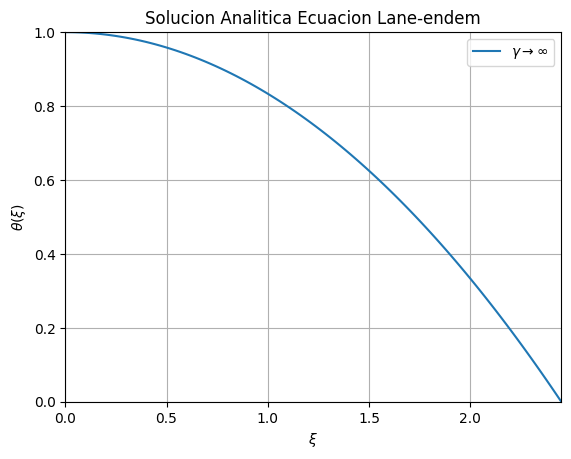

In [ ]:
fig, ax = plt.subplots()
# geff -> oo
xs = np.linspace(0,np.sqrt(6),100)
xis = 1 - xs**2/6
ax.plot(xs,xis, label=r"$\gamma\rightarrow\infty$")

ax.legend()
ax.set_ylim(0,1)
ax.set_title(r"Solucion Analitica Ecuacion Lane-endem")
ax.set_xlabel(r"$\xi$")
ax.set_ylabel(r"$\theta(\xi)$")
ax.grid()
ax.margins(0)

Nótese que esta solución es acotada y llega hasta $\xi = \sqrt{6}$

La solución analítica para los casos con $\gamma=2$ y $\gamma=6/5$ no es posible de obtenerla usando con los métodos de `sympy` pero es bien conocida:

$$
\gamma=2: \theta(\xi)=\frac{\sin \xi}{\xi}
$$

$$
\gamma=6 / 5 :\theta(\xi)=\frac{1}{\sqrt{1+\xi^2 / 3}}
$$

Mostremos que si satisfacen la ecuación:

In [ ]:
sp.simplify( LE.subs(g,2).subs(t(x),sp.sin(x)/x) )

0

In [ ]:
sp.simplify(sp.simplify( LE.subs(g,sp.Rational(6,5)).subs(t(x), 1/sp.sqrt(1+x**2/3))) )

0

### Gráficos

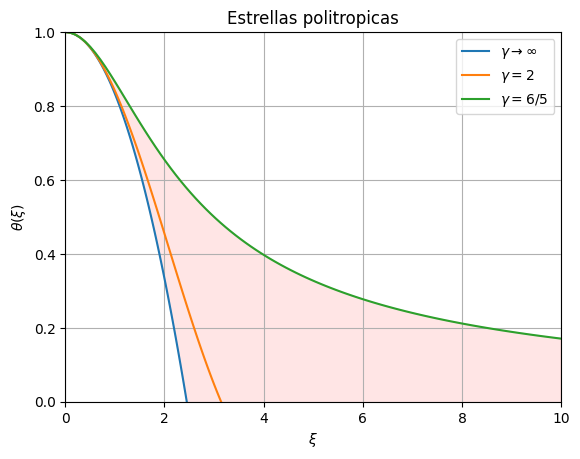

In [ ]:
fig, ax = plt.subplots()
ax.set_title('Estrellas politropicas')

# geff -> oo
xs = np.linspace(0,np.sqrt(6),100)
xis = 1 - xs**2/6 # xsi
ax.plot(xs,xis, label=r"$\gamma\rightarrow\infty$")

# geff = 2
xs = np.linspace(1e-3,np.pi,100)
xis = np.sin(xs)/xs # xsi
ax.plot(xs,xis, label=r"$\gamma=2$")

# geff = 6/5
xs = np.linspace(0,10.0,100)
xis = 1/(1+xs**2/3)**0.5  # xsi
ax.plot(xs,xis, label=r"$\gamma=6/5$")

# geff = 6/5
xs_lim = np.linspace(0,10.0,100)
xis_up = 1/(1+xs_lim**2/3)**0.5
xis_down = 1 - xs_lim**2/6
ax.fill_between(xs_lim,xis_down,xis_up,color='r',alpha=0.1)

ax.legend()
ax.set_ylim(0,1)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel(r"$\theta(\xi)$")
ax.grid()
ax.margins(0)

Todas las soluciones para $\gamma\geq 6/5$ están contenidas en esa region sombreada.

### **Solución numérica**

$$
\frac{1}{\xi^{2}} \frac{d}{d \xi}\left(\xi^{2} \frac{d\theta}{d \xi}\right)+\theta^{\frac{1}{\gamma-1}}=0
$$

Que se puede escribir como:
$$
\frac{d^2\theta}{d \xi^2}=-\frac{2}{\xi}\frac{d\theta}{d \xi}-\theta^{\frac{1}{\gamma-1}}
$$

In [ ]:
def lane_emden(x, Y, gamma=5/3):

  teta, tetap = Y

  # ecuacion linealizada
  dtetadr = tetap # 1r derivada
  dtetapdr = -2/x*tetap - abs(teta)**(1/(gamma-1)) # 2d derivada

  return np.array([dtetadr, dtetapdr])


# funcion para singularidad
def surface(t, Y, gamma):
  """Esta rutina detecta cuando la solución a la ecuación llega a la superficie
  que es cuando theta=0 """

  teta, tetap = Y # en la superficie teta=teta
  return teta

Vamos a resolver el sistema de ecuaciones usando `solve_ivp` porque es necesario detectar cuando la solución llega a la superficie y no seguir con la integración:

In [ ]:
xs = np.linspace(1e-2, 10, 1000) # dominio de xsi
Yo = [1, 0] # ICS

gamma = "5/3"

# solucion solve_ivp (ec, (i,f), dominio, ics, args, event=signularidad)
sol = solve_ivp(lane_emden, [xs[0],xs[-1]], t_eval=xs , y0=Yo, args=(eval(gamma),), events=surface)

tetas = sol.y[0]
tetaps = sol.y[1]

Si miramos el objeto solución:

In [ ]:
sol
# note, xsi= 3.657e+00, teta=0

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 1.000e-02  2.000e-02 ...  9.990e+00  1.000e+01]
        y: [[ 1.000e+00  1.000e+00 ... -2.560e+01 -2.610e+01]
            [ 0.000e+00 -5.833e-03 ... -4.925e+01 -5.046e+01]]
      sol: None
 t_events: [array([ 3.657e+00])]
 y_events: [array([[ 0.000e+00, -2.021e-01]])]
     nfev: 128
     njev: 0
      nlu: 0

Vemos que `t_events` marca el valor de $\xi$ en el que está la superficie del cuerpo.  Podemos entonces solamente tomar la solución hasta allí:

In [ ]:
# filtro para saber si hay eventos

if len(sol.t_events[0]) > 0:
  x_surf = sol.t_events[0][0]
  teta_surf = sol.y_events[0][0,0]
  tetap_surf = sol.y_events[0][0,1]

else:
  x_surf = xs[-1]
  teta_surf = tetas[-1]
  tetap_surf = tetaps[-1]

# valores de la superficie
x_surf, teta_surf, tetap_surf

(3.656964586122009, 0.0, -0.20205423608867623)

Finalmente, si hay superficie volvermos a hacer los arreglos solo hasta la superficie interpolando:

In [ ]:
# nuevo dominio xsi
xns = np.linspace(xs[0], x_surf, 100)

# interpolando la solucion
tetans = np.interp(xns, xs, tetas) # teta
tetapns = np.interp(xns, xs, tetaps) # tta prima

Ahora si graficamos:

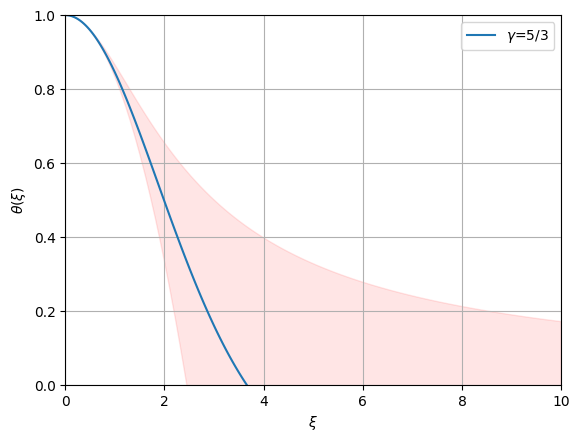

In [ ]:
fig, ax = plt.subplots()
ax.plot(xns, tetans, label=rf"$\gamma$={gamma}")

# Límites
ax.fill_between(xs_lim, xis_down, xis_up, color='r',alpha=0.1)

# Decoration
ax.legend()
ax.set_ylim(0,1)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel(r"$\theta(\xi)$")
ax.grid()
ax.margins(0)

Diseñemos una rutina que lo haga para cualquier valor de $\gamma$:

In [ ]:
# recibe gamma y devuleve solucion lane-endem

def politropa(gamma, xmax=10):
  global surface

  xs = np.linspace(1e-2, xmax, 1000)
  Yo = [1,0]

  # Resolvemos
  sol = solve_ivp(lane_emden, [xs[0],xs[-1]], t_eval=xs, y0=Yo, args=(gamma,), events=surface)
  tetas = sol.y[0]
  tetaps = sol.y[1]

  # Buscamos evento en superficie
  if len(sol.t_events[0])>0:
    hasurf = True
    x_surf = sol.t_events[0][0]
    teta_surf = sol.y_events[0][0,0]
    tetap_surf = sol.y_events[0][0,1]
  else:
    hasurf = False
    x_surf = xs[-1]
    teta_surf = tetas[-1]
    tetap_surf = tetaps[-1]

  # Interpolamos
  xns = np.linspace(xs[0], x_surf, 100)
  tetans = np.interp(xns, xs, tetas)
  tetapns = np.interp(xns, xs, tetaps)

  return hasurf, xns, tetans, tetapns

Hagamos un código interactivo para verlo:

In [ ]:
from ipywidgets import interact, widgets

In [ ]:
@interact( gamma=(6/5, 10, 0.01), continuous_update=False )

def interactua_lane_emden(gamma=6/5):
  hasurf, xns, tetans, tetapns = politropa(gamma)
  fig, ax = plt.subplots()
  ax.plot(xns, tetans, label=rf"$\gamma$={gamma}")

  # Límites
  ax.fill_between(xs_lim, xis_down, xis_up, color='r', alpha=0.1)

  # Decoration
  ax.legend()
  ax.set_ylim(0,1)
  ax.set_xlabel(r"$\xi$")
  ax.set_ylabel(r"$\theta(\xi)$")
  ax.grid()
  ax.margins(0)

  plt.show()

interactive(children=(FloatSlider(value=1.2, description='gamma', max=10.0, min=1.2, step=0.01), Output()), _d…

## Estrella politrópica

Vamos a comparar con el modelo realista:

In [ ]:
X = 0.73 # h
Z = 0.02 # resto de metales
Mmol = 4/(3+5*X-Z)*1e-3 # [kg/mol]

G = 6.67e-11 # [m^3/(kg s^2)]
R = 8.31446261815324 # [J/kg/mol]

Mmol

0.0006033182503770739

Supongamos un modelo con $\gamma = 5/3$ (gas monoatómico)

In [ ]:
gamma =  1.3 # gamma = 1.67=5/3 monoatomic
cp = gamma/(gamma-1)*R/Mmol

Ms = 2e30 # [kg]
Rs = 7.96e8 # [m]
g0 = G*Ms/Rs**2 # gravedad en superfie
T0 = g0*Rs/cp # para t_centro

cp, g0, T0

(59718.62775488564, 210.53761268654833, 2806292.54219228)

Calculamos los límites de la polítropa:

In [ ]:
hasurf, xns, tetans, tetapns = politropa(gamma)
gamma1 = 5/3
x0 = xns[-1] # xsi superf
tetap0 = tetapns[-1] # tetprima superf

x0, tetap0

(8.494784667702195, -0.02669405820187938)

Grafiquemos la politropa:

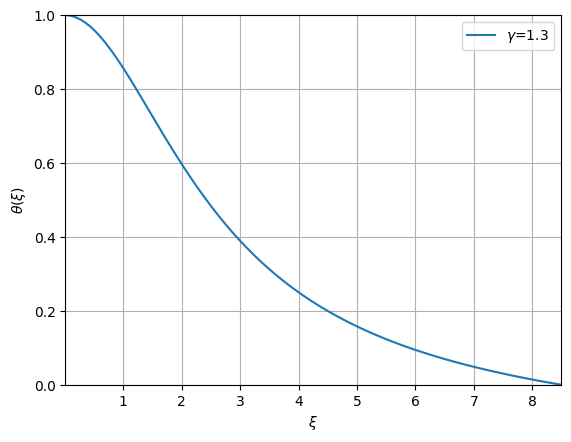

In [ ]:
fig, ax = plt.subplots()
ax.plot(xns, tetans, label=rf"$\gamma$={gamma}")

# Decoration
ax.legend()
ax.set_ylim(0,1)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel(r"$\theta(\xi)$")
ax.grid()
ax.margins(0)

Podemos ahora usar estos límites para calcular la temperatura central de la estrella:

* el interior solar deberia superar los 7 millones kelvin para poder fusionar

In [ ]:
Tc = -T0/(x0*tetap0)
Tc

12375591.473008506

Modelos realistas del interior del sol predicen una temperatura de 15.6 millones de grados, así que esté estimativo, relativamente grueso no está mal.

Y el valor de $\lambda$: escala de tamaño de la estrella

In [ ]:
# en la superficie
lamb = Rs/x0 # [m]
lamb
# el tamaño de la estrella es 8 veces este valor

93704552.98607525

Podemos ahora depejar de la definición de lambda el valor de la densidad central:

In [ ]:
# densidad central
rhoc = cp*Tc/(4*np.pi*G*lamb**2) #[si]
rhoc

100419.64920088997

Teniendo ya el valor de $T_c$ y $\rho_c$ podemos hacer el perfil de temperatura para la estrella:

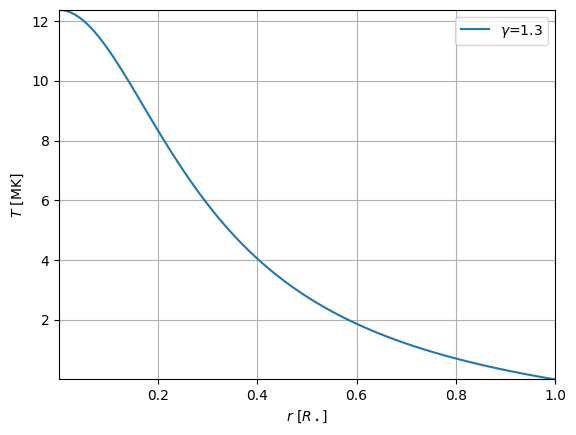

In [ ]:
fig, ax=plt.subplots()

# volviendo a dimensiones
rs = xns*lamb # radio
Ts = tetans*Tc # temperatura

ax.plot(rs/Rs, Ts/1e6, label=rf"$\gamma$={gamma}")

# Decoration
ax.legend()
ax.set_xlabel(r"$r$ [$R_\star$]")
ax.set_ylabel(r"$T$ [MK]")
ax.grid()
ax.margins(0)

Teniendo la presión y temperatura central podemos calcular la presión con la ley del gas ideal:

In [ ]:
pc = R*Tc*rhoc/Mmol # GI
print(f"Presión central: {pc/1e5:g} bar")

Presión central: 1.71266e+11 bar


Los perfiles de presión y densidad los calculamos con las homentrópicas:

$$
T \rho^{1-\gamma}=T_c \rho_c^{1-\gamma}, T^\gamma p^{1-\gamma}=T_c^\gamma p_c^{1-\gamma}
$$

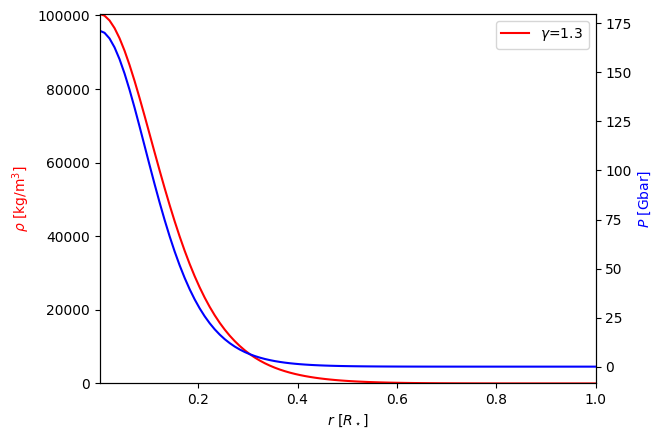

In [ ]:
# Relacion adiabatica
rhos = (Tc*rhoc**(1-gamma)/Ts)**(1/(1-gamma))  # densidad
ps = (Tc**gamma*pc**(1-gamma)/Ts**gamma)**(1/(1-gamma)) # presion


fig, ax = plt.subplots()

ax.plot(rs/Rs, rhos, color='r',label=rf"$\gamma$={gamma}")

axp = ax.twinx()
axp.plot(rs/Rs, ps/1e5/1e9, color='b')

# Decoration
ax.legend()
ax.set_xlabel(r"$r$ [$R_\star$]")
ax.set_ylabel(r"$\rho$ [kg/m$^3$]",color='r')
axp.set_ylabel(r"$P$ [Gbar]",color='b')
ax.margins(0)

Miremos cuánta masa tiene el modelo:

$$
M = \int_0^{R_\star} 4\pi r^2\rho(r)\;\mathrm{d}r
$$

Primero interpolamos la densidad:

In [ ]:
rho_fun = interp1d(rs, rhos)

Ahora integramos:

In [ ]:
xns[0]*Rs

7960000.0

In [ ]:
import warnings
warnings.filterwarnings('ignore')

integrando = lambda r: 4*np.pi*r**2*rho_fun(r)
quad(integrando, xns[0]*Rs, Rs)

(2.0077927827124004e+30, 5.312504020946699e+25)

Que esta desfasado por 1% de la masa real. Modifique el valor de $\gamma$ para obtener un valor más cercano.

Podemos reunir estos resultados en una rutina que nos permita variar el valor de $\gamma$:

In [ ]:
@interact(gamma=(6/5,1.5,0.01))

def interior_estrella(gamma=1.333):
  X = 0.73
  Z = 0.02
  Mmol = 4/(3+5*X-Z)*1e-3 #kg/mol
  R = 8.31446261815324 #J/kg/mol
  G = 6.67e-11 # m^3/(kg s^2)
  cp = gamma/(gamma-1)*R/Mmol

  # Propiedades globales del Sol
  Ms = 2e30 # kg
  Rs = 7.96e8 #m
  g0 = G*Ms/Rs**2
  T0 = g0*Rs/cp

  # Solución a la ecuación de Lane-Emden
  hasurf, xns, tetans, tetapns = politropa(gamma)

  x0 = xns[-1]
  tetap0 = tetapns[-1]
  lamb = Rs/x0

  # Calculo de temperatura y densidad central
  Tc = -T0/(x0*tetap0)
  rhoc = cp*Tc/(4*np.pi*G*lamb**2)
  pc = R*Tc*rhoc/Mmol
  print(f"Temperatura central: {Tc/1e6} MK")
  print(f"Densidad central: {rhoc/1e3} g/cm3")
  print(f"Presión central: {pc/1e5:g} bar")

  # Perfil de presión y densidad
  rs = xns*lamb
  Ts = tetans*Tc
  rhos = (Tc*rhoc**(1-gamma)/Ts)**(1/(1-gamma))
  ps = (Tc**gamma*pc**(1-gamma)/Ts**gamma)**(1/(1-gamma))

  # Calculo de la masa total
  rho_fun = interp1d(rs,rhos)
  integrando = lambda r: 4*np.pi*r**2*rho_fun(r)
  M,dM = quad(integrando,xns[0]*Rs,Rs)
  print(f"Masa total: {M} kg")

interactive(children=(FloatSlider(value=1.333, description='gamma', max=1.5, min=1.2, step=0.01), Output()), _…

<br><br><br><br><br>

____


<br>

## **Minitarea 4:** Luminosidad de estrellas

____
<br>

Formula integral para la Luminosidad:

$$
L = \int_0^{R_\star} 4\pi r^2\rho(r) \epsilon(r) \;\mathrm{d}r
$$


Se tomó la misma funcion previa ```interior_estrella()``` añadiendo el calculo para la luminosidad, cuyo valor se imprime al final de la funcion.


In [ ]:

def interior_estrella_mod(gamma):
  X = 0.73
  Z = 0.02
  Mmol = 4/(3+5*X-Z)*1e-3 #kg/mol
  R = 8.31446261815324 #J/kg/mol
  G = 6.67e-11 # m^3/(kg s^2)
  cp = gamma/(gamma-1)*R/Mmol

  # Propiedades globales del Sol
  Ms = 2e30 # kg
  Rs = 7.96e8 #m
  g0 = G*Ms/Rs**2
  T0 = g0*Rs/cp

  # Solución a la ecuación de Lane-Emden
  hasurf, xns, tetans, tetapns = politropa(gamma)

  x0 = xns[-1]
  tetap0 = tetapns[-1]
  lamb = Rs/x0

  # Calculo de temperatura y densidad central
  Tc = -T0/(x0*tetap0)
  rhoc = cp*Tc/(4*np.pi*G*lamb**2)
  pc = R*Tc*rhoc/Mmol
  print(f"Temperatura central: {Tc/1e6} MK")
  print(f"Densidad central: {rhoc/1e3} g/cm3")
  print(f"Presión central: {pc/1e5:g} bar")

  # Perfil de presión y densidad
  rs = xns*lamb
  Ts = tetans*Tc
  rhos = (Tc*rhoc**(1-gamma)/Ts)**(1/(1-gamma))
  ps = (Tc**gamma*pc**(1-gamma)/Ts**gamma)**(1/(1-gamma))

  # Calculo de la masa total
  rho_fun = interp1d(rs,rhos) # funcion densidad
  integrando = lambda r: 4*np.pi*r**2*rho_fun(r)
  M,dM = quad(integrando, xns[0]*Rs,Rs)
  print(f"Masa total: {M} kg")


  # Calculo de luminosidad
  n = 4
  T0 = 15e6 # [k]
  ϵ0 = 0.0125 # [J/kg/s]

  ϵ = ϵ0*(Ts/T0)**n # tasa de produccion de H por fusion
  ϵ_fun = interp1d(rs, ϵ) # funcion tasa produccion

  integrando_lum = lambda r: 4*np.pi*r**2*rho_fun(r)*ϵ_fun(r)
  L, dL = quad(integrando_lum, xns[0]*Rs, Rs) # integral de luminosidad

  print(f"Luminosidad: {L} [J] ± {dL/L*100}%")


1. Calcular para γ = 5/3 y γ = 4/3 la luminosidad predicha para el Sol por el modelo politrópico.


In [ ]:
interior_estrella_mod(gamma=5/3)

Temperatura central: 6.583005831286722 MK
Densidad central: 5.7112562527337625 g/cm3
Presión central: 5.18136e+09 bar
Masa total: 2.0109620553943193e+30 kg
Luminosidad: 1.6532790999601442e+26 [J] ± 0.0006617280357234557%


In [ ]:
interior_estrella_mod(gamma=4/3)

Temperatura central: 10.419071944701674 MK
Densidad central: 51.66247291468781 g/cm3
Presión central: 7.41809e+10 bar
Masa total: 2.0057069645555044e+30 kg
Luminosidad: 1.2624565362758303e+27 [J] ± 0.00035064713437230895%


<br>

2. La verdadera luminosidad del Sol es 3.8×10²⁶ J. ¿Cuál es el valor de γ que mejor predice el valor real de la luminosidad solar? ¡ese es el γ que se usa en modelos realistas del interior solar!
<br><br>

como este valor ($L_{\odot}=3.8×10²⁶$ J) esta entre los dos resultados obtenidos:

* para $\gamma=4/3$, $\quad L_{\odot}=1.26e^{27}$ J
* para $\gamma=5/3$, $\quad L_{\odot}=1.65e^{26}$ J

entonces el $\gamma_{\text{eff}}$ debera estar entre el intervalo $[4/3, 5/3]=[1.33, 1.66]$

se evidencia que la luminosidad aumenta si $\gamma$  disminuye, lo que corresponde con estrellas de mayor radio.

probando con valores intermedios para encontrar un gamma que represente bien la lumninosidad del sol se dió con el siguiente valor:

In [ ]:
gamma_eff = 4.331/3
interior_estrella_mod(gamma_eff)
print(f'\nPara: γ_eff = {gamma_eff}')

Temperatura central: 7.878373061625466 MK
Densidad central: 15.455022201726722 g/cm3
Presión central: 1.67801e+10 bar
Masa total: 2.0056672467271776e+30 kg
Luminosidad: 3.8091213900199754e+26 [J] ± 0.002060704839434667%

Para: γ_eff = 1.4436666666666669


3. Hacer un modelo del interior de Próxima Centauri (masa 0.123 masas solares, radio 0.145 radios solares, 0.0017 luminosidades solares). Para estrellas enanas, las temperaturas centrales son más bajitas y los valores de la ley de la tasa de producción de energía son ϵ₀ = 0.00003875, Tₒ = 8x10⁶ K, n=5.  Encontrar el valor del índice politrópico que predice correctamente la luminosidad de Próxima Centauri. ¿Cuál es la temperatura y densidad predichas para esta estrellas con el modelo politrópico?.


Asumiendo que este tipo de estrellas tiene la misma composicion que el sol en cuanto a los valores $X$ y $Z$

In [ ]:

def interior_estrella_enana(gamma):

  X = 0.73
  Z = 0.02
  Mmol = 4/(3+5*X-Z)*1e-3 # kg/mol
  R = 8.31446261815324    # J/kg/mol
  G = 6.67e-11            # m^3/(kg s^2)
  cp = gamma/(gamma-1)*R/Mmol

  # Propiedades globales del proxima centauri
  Ms = 0.123*(2e30)   # kg
  Rs = 0.145*(7.96e8) # m
  g0 = G*Ms/Rs**2
  T0 = g0*Rs/cp


  # Solución a la ecuación de Lane-Emden
  hasurf, xns, tetans, tetapns = politropa(gamma)

  x0 = xns[-1]
  tetap0 = tetapns[-1]
  lamb = Rs/x0

  # Calculo de temperatura y densidad central
  Tc = -T0/(x0*tetap0)
  rhoc = cp*Tc/(4*np.pi*G*lamb**2)
  pc = R*Tc*rhoc/Mmol
  print(f"Temperatura central: {Tc/1e6} MK")
  print(f"Densidad central: {rhoc/1e3} g/cm3")
  print(f"Presión central: {pc/1e5:g} bar")

  # Perfil de presión y densidad
  rs = xns*lamb
  Ts = tetans*Tc
  rhos = (Tc*rhoc**(1-gamma)/Ts)**(1/(1-gamma))
  ps = (Tc**gamma*pc**(1-gamma)/Ts**gamma)**(1/(1-gamma))

  # Calculo de la masa total
  rho_fun = interp1d(rs,rhos) # funcion densidad
  integrando = lambda r: 4*np.pi*r**2*rho_fun(r)
  M,dM = quad(integrando, xns[0]*Rs,Rs)
  print(f"Masa total: {M} kg")


  # Calculo de luminosidad
  n = 5
  T0 = 8e6 # [k]
  ϵ0 = 0.00003875 # [J/kg/s]

  ϵ = ϵ0*(Ts/T0)**n # tasa de produccion de H por fusion
  ϵ_fun = interp1d(rs, ϵ) # funcion tasa produccion

  integrando_lum = lambda r: 4*np.pi*r**2*rho_fun(r)*ϵ_fun(r)
  L, dL = quad(integrando_lum, xns[0]*Rs, Rs) # integral de luminosidad

  print(f"Luminosidad: {L} [J] ± {dL/L*100}%\n")



  # GRAFICA
  fig, ax = plt.subplots()
  fig.suptitle("Perfiles de temperatura y densidad de proxima centauri")
  ax.plot(rs/Rs, rhos, color='r')

  axp = ax.twinx()
  axp.plot(rs/Rs, Ts/1e6, color='b')
  axp.set_ylabel(r"T [MK]",color='b')
  # axp.legend()


  ax.set_xlabel(r"$r$ [$R_\star$]")
  ax.set_ylabel(r"$\rho$ [kg/m$^3$]",color='r')
  ax.margins(0)
  # ax.legend()


la luminosidad de proxima centauri es: $L_{\star} = 0.0017 L_{\odot}=6.46e23$

In [ ]:
l_sun = 3.8e26
l_proxima = 0.0017*l_sun
print(f'Luminosidad proxima centauri: {l_proxima} J')

Luminosidad proxima centauri: 6.46e+23 J


ahora buscando un gamma adecuado para este modelo de estrellas se encontró el siguiente

Modelo politropico proxima centauri:

Temperatura central: 6.745339112467267 MK
Densidad central: 651.4139712064223 g/cm3
Presión central: 6.05548e+11 bar
Masa total: 2.4672296160791185e+29 kg
Luminosidad: 6.465589167086999e+23 [J] ± 0.0031157787808334934%



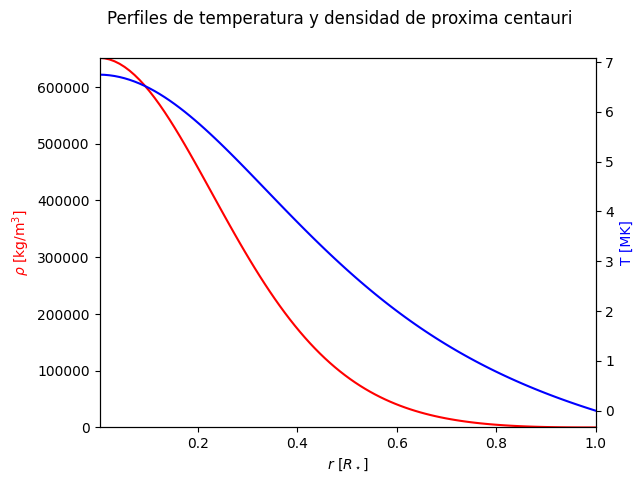

In [ ]:
print('Modelo politropico proxima centauri:\n')

gamma = 1.4378
interior_estrella_enana(gamma)